# Data preparation
Using datasets read json file in

In [50]:
import os
print(os.listdir('../proteinnet/'))

['proteinnet_train.json', 'proteinnet_test.json', 'proteinnet_valid.json']


In [51]:
import os

# 先檢查檔案是否存在
files_to_check = {
    "train":'../proteinnet/proteinnet_train.json',
    "validation":'../proteinnet/proteinnet_valid.json',
    "test":'../proteinnet/proteinnet_test.json'
}

print("檢查檔案是否存在:")
for name, path in files_to_check.items():
    exists = os.path.exists(path)
    if exists:
        size = os.path.getsize(path) / (1024*1024)  # MB
        print(f"✓ {name}: {path} ({size:.1f} MB)")
    else:
        print(f"✗ {name}: {path} (不存在)")

檢查檔案是否存在:
✓ train: ../proteinnet/proteinnet_train.json (2464.2 MB)
✓ validation: ../proteinnet/proteinnet_valid.json (20.0 MB)
✓ test: ../proteinnet/proteinnet_test.json (5.1 MB)


In [52]:
# import shutil
# # 清除所有相關快取
# cache_dirs = [
#     os.path.expanduser("~/.cache/huggingface/datasets"),
#     os.path.expanduser("~/.cache/huggingface/modules"),
#     os.path.expanduser("~/.cache/pip"),
# ]

# for cache_dir in cache_dirs:
#     if os.path.exists(cache_dir):
#         try:
#             shutil.rmtree(cache_dir)
#             print(f"已清除: {cache_dir}")
#         except Exception as e:
#             print(f"清除失敗 {cache_dir}: {e}")

# print("快取清除完成，請重新啟動 kernel")

In [53]:
from datasets import DatasetDict, Dataset, load_dataset
import json

my_data_files = {
    "train":'../proteinnet/proteinnet_train.json',
    "validation":'../proteinnet/proteinnet_valid.json',
    "test":'../proteinnet/proteinnet_test.json'
}

def json_lines_generator(filepath, max_samples=None):
    """
    這個產生器會逐行讀取 JSON Lines 檔案，並 yield 每一筆紀錄。
    """
    print(f"INFO: Starting to stream data from {filepath}")
    sample_count = 0

    with open(filepath, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            if max_samples and sample_count >= max_samples:
                break

            if line.strip():  # 確保不是空行
                try:
                    data = json.loads(line)
                    if isinstance(data, dict):
                        yield data
                        sample_count+=1
                    elif isinstance(data, list):
                        if len(data) > 0 and isinstance(data[0], dict):
                            for item in data:
                                if isinstance(item, dict):
                                    yield item
                                    sample_count+=1
                                    if max_samples and sample_count >= max_samples:
                                        return
                        else:
                            yield {"data":data}
                            sample_count += 1
                    else:
                        yield {"data":data}
                        sample_count += 1             
                except json.JSONDecodeError as e:
                    print("Parsing Error")
                    continue

## Using generator to get dataset from json file

In [54]:
MAX_LEN = 128
PAD_TOKEN_ID = -100

In [55]:
def vectorized_chunking(dataset_split, max_len=MAX_LEN):
    all_chunks = []
    for record in dataset_split:
        if not isinstance(record, dict):
            continue

        primary = record.get('primary', [])
        tertiary = record.get('tertiary', [])
        
        if len(primary) <= max_len:
            yield{
                'primary': primary,
                'tertiary': tertiary
            }
        
        else:
            num_chunks = (len(primary) + max_len - 1)//max_len

            for i in range(num_chunks):
                start_idx = i * max_len
                end_idx = min(start_idx + max_len, len(primary))

                yield{
                    'primary': primary[start_idx:end_idx],
                    'tertiary': tertiary[start_idx:end_idx]
                }

In [56]:
raw_datasets = DatasetDict()
# 4. 使用 from_generator 建立資料集
for split_name, file_path in my_data_files.items():
    # from_generator 會從我們的產生器中安全地讀取資料並建立 Arrow 快取
    # 它內部的寫入機制會自動分塊，避免 2GB 問題
    raw_datasets[split_name] = Dataset.from_generator(
        json_lines_generator, 
        gen_kwargs={"filepath": file_path}
    )

# 5. 檢查是否成功
print("資料集成功載入：")
print(raw_datasets)

資料集成功載入：
DatasetDict({
    train: Dataset({
        features: ['id', 'primary', 'evolutionary', 'secondary', 'tertiary', 'protein_length', 'valid_mask'],
        num_rows: 25115
    })
    validation: Dataset({
        features: ['id', 'primary', 'evolutionary', 'secondary', 'tertiary', 'protein_length', 'valid_mask'],
        num_rows: 224
    })
    test: Dataset({
        features: ['id', 'primary', 'evolutionary', 'secondary', 'tertiary', 'protein_length', 'valid_mask'],
        num_rows: 40
    })
})


/home/lovem/miniconda3/lib/python3.9/site-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [57]:
chunked_datasets = DatasetDict()

for split_name, dataset_split in raw_datasets.items():
    print(f"INFO: Creating chunked dataset for '{split_name}' split...")
    chunked_datasets[split_name] = Dataset.from_generator(
        vectorized_chunking,
        gen_kwargs={"dataset_split": dataset_split}
    )

print("\n分割後的資料集已建立：")

INFO: Creating chunked dataset for 'train' split...
INFO: Creating chunked dataset for 'validation' split...
INFO: Creating chunked dataset for 'test' split...

分割後的資料集已建立：


## Trying to generate contact map on first data in train dataset

In [58]:
import numpy as np
iterator = iter(chunked_datasets['train'])
first_example = next(iterator)
tertiary = first_example['tertiary']

coords = np.array(tertiary)

diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]# 透過廣播機制來快速建立每個點與點之間的距離
dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))
dist_matrix.shape


(41, 41)

In [59]:
CONTACT_THRESHOLD = 8.0

contact_map = (dist_matrix < CONTACT_THRESHOLD).astype(np.int8)

np.fill_diagonal(contact_map, 0)

# 現在，`contact_map` 就是您需要的 L x L 接觸圖標籤了
print("--- 計算得到的距離矩陣 (前 5x5) ---")
print(dist_matrix[:, :])

print("\n--- 根據 8.0Å 閾值生成的接觸圖 (前 5x5) ---")
print(contact_map[:, :])

--- 計算得到的距離矩陣 (前 5x5) ---
[[ 0.          3.80356714  5.97506235 ... 17.36552441 18.41207184
  21.83670067]
 [ 3.80356714  0.          3.80372568 ... 16.02420833 17.63287922
  20.68765181]
 [ 5.97506235  3.80372568  0.         ... 13.48875072 14.74213336
  17.70230563]
 ...
 [17.36552441 16.02420833 13.48875072 ...  0.          3.8030454
   5.36830959]
 [18.41207184 17.63287922 14.74213336 ...  3.8030454   0.
   3.80326696]
 [21.83670067 20.68765181 17.70230563 ...  5.36830959  3.80326696
   0.        ]]

--- 根據 8.0Å 閾值生成的接觸圖 (前 5x5) ---
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]


In [60]:
from transformers import AutoTokenizer
from transformers.tokenization_utils_fast import PreTrainedTokenizerFast
from transformers.tokenization_utils import PreTrainedTokenizer
from typing import Union

tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")# Load the tokenizer, we need to use it on datapreprocess

## Using map function to preprocess dataset

In [61]:
def preprocess_function(examples):
    labels_batch = []# Preprocess part, encoding and labelize
    masks_batch = []
    model_inputs = tokenizer(
        examples['primary'],
        truncation=True,
        max_length=MAX_LEN,
        padding='max_length'
    )# Prepare model input (tokenize the protein sequence here)
    
    for tertiary_coords in examples['tertiary']:
        # 填充座標
        num_coords = len(tertiary_coords)
        padded_coords = np.pad(
            np.array(tertiary_coords, dtype=np.float32),
            ((0, MAX_LEN - num_coords), (0,0)), # 不滿MAX_LEN填充(0,0)
            'constant',
            constant_values=0
        )

        diff = padded_coords[:,np.newaxis,:] - padded_coords[np.newaxis,:,:]
        dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))
        contact_map = (dist_matrix < CONTACT_THRESHOLD).astype(np.float32)
        np.fill_diagonal(contact_map, 0)

        valid_mask = np.zeros((MAX_LEN, MAX_LEN), dtype=np.float32)# 生成一個L*L的矩陣
        valid_mask[:num_coords, :num_coords] = 1.0# 將非填充的地方設為1
        contact_map = contact_map * valid_mask
        
        labels_batch.append(contact_map)
        masks_batch.append(valid_mask)

    model_inputs['labels'] = labels_batch
    model_inputs['labels_mask'] = masks_batch
    return model_inputs


In [62]:
final_dataset = chunked_datasets.map(
    preprocess_function,
    batched=True,
    batch_size=100
)

### Map 完成後，set_format()

In [63]:
final_dataset.set_format(
    type='torch',
    columns=['input_ids','attention_mask','labels','labels_mask']
)

In [64]:
print("\n最終處理完成的資料集：")
print(final_dataset)
print(np.array(final_dataset['train'][0]['labels']).shape)
for k, v in final_dataset['train'][0].items():
    print(f"{k}:{v}")


最終處理完成的資料集：
DatasetDict({
    train: Dataset({
        features: ['primary', 'tertiary', 'input_ids', 'attention_mask', 'labels', 'labels_mask'],
        num_rows: 55296
    })
    validation: Dataset({
        features: ['primary', 'tertiary', 'input_ids', 'attention_mask', 'labels', 'labels_mask'],
        num_rows: 467
    })
    test: Dataset({
        features: ['primary', 'tertiary', 'input_ids', 'attention_mask', 'labels', 'labels_mask'],
        num_rows: 113
    })
})
(128, 128)
input_ids:tensor([ 0,  8,  9, 15, 14, 16, 16,  9,  4,  9,  9, 23, 16, 17,  7, 23, 10, 20,
        15, 10, 22,  8, 11,  9, 20,  7, 21, 10, 23,  9, 15, 15, 23,  9,  9, 15,
        18,  9, 10, 16, 16, 10,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1, 

In [65]:
print(type(final_dataset['train']))

<class 'datasets.arrow_dataset.Dataset'>


# Loading Model and Model Definition

In [66]:
from transformers import AutoModelForMaskedLM

base_model = AutoModelForMaskedLM.from_pretrained("facebook/esm2_t6_8M_UR50D")

Some weights of the model checkpoint at facebook/esm2_t6_8M_UR50D were not used when initializing EsmForMaskedLM: ['esm.embeddings.position_embeddings.weight']
- This IS expected if you are initializing EsmForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing EsmForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [67]:
import torch
import torch.nn as nn

class ESMForContactMapPrediction(nn.Module):
    def __init__(self, base_model, cnn_hidden_dim = 64):# 2-dimensional binary classification
        super().__init__()
        self.base_model = base_model
        self.drop_out = nn.Dropout(0.1)
        self.loss_fn = nn.BCEWithLogitsLoss(reduction='none')# To get elementwise loss
        esm_hidden_size = base_model.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Conv2d(in_channels=esm_hidden_size*2, out_channels=cnn_hidden_dim, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=cnn_hidden_dim, out_channels=1, kernel_size=1)
        )
    def forward(self, input_ids, attention_mask = None):
        outputs = self.base_model(
            input_ids = input_ids, 
            attention_mask = attention_mask,
            output_hidden_states = True
        )
        embeddings = outputs.hidden_states[-1]
        B, L, D = embeddings.shape# 1D amino acid embedding

        left = embeddings.unsqueeze(2).expand(B, L, L, D)
        right = embeddings.unsqueeze(1).expand(B, L, L, D)

        pairwise_feature = torch.cat((left, right), dim=-1)# B, L, L, 2*D
        # Pytorch Conv2d need (B, Channels, Height, Width)
        # We need to change (B, L, L, 2D) -> (B, 2D, L, L)
        pairwise_feature = pairwise_feature.permute(0, 3, 1, 2)

        # Use prediction head to get logits
        logits = self.classifier(pairwise_feature)# (B, 1, L, L)

        final_logits = logits.squeeze(1)# (B, L, L)

        return final_logits        

In [68]:
model = ESMForContactMapPrediction(base_model=base_model)

In [69]:
from transformers.optimization import get_linear_schedule_with_warmup
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import DataLoader
from accelerate import Accelerator

In [70]:
def evaluate(model, eval_loader, accelerator:Accelerator):
    model.eval()
    total_eval_loss = 0
    total_valid_elements = 0

    with torch.no_grad():
        for batch in eval_loader:
            logits = model(input_ids = batch['input_ids'], attention_mask = batch['attention_mask'])
            labels = batch['labels']
            labels_mask = batch['labels_mask']

            loss_per_element = model.loss_fn(logits, labels)
            masked_loss = loss_per_element * labels_mask
            batch_loss = masked_loss.sum()
            num_valid_elements = labels_mask.sum()

            gathered_batch_losses = accelerator.gather_for_metrics(batch_loss)
            gathered_num_valid = accelerator.gather_for_metrics(num_valid_elements)

            total_eval_loss += gathered_batch_losses.sum().item()
            total_valid_elements += gathered_num_valid.sum().item()

    avg_eval_loss = total_eval_loss / (total_valid_elements + 1e-8)

    # 將模型切換回訓練模式，以便進行下一個 epoch 的訓練
    model.train()

    return avg_eval_loss

In [71]:
import math

def train(model, train_dataset, validate_dataset):
    # Some Parameter we need
    patience = 5
    logging_step = 1000
    global_steps = 0
    eval_steps = 1500
    best_val_loss = float('inf')
    best_model_state_dict = None
    epochs_no_improve = 0
    per_device_train_batch_size = 4
    per_device_eval_batch_size = 8

    # Using Accelerator framework
    accelerator = Accelerator(mixed_precision='bf16', gradient_accumulation_steps=2)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=5e-4,
        weight_decay=0.01
    )

    shuffled_train_dataset = train_dataset.shuffle(seed=42)
    train_loader = DataLoader(shuffled_train_dataset, batch_size=per_device_train_batch_size)
    validate_loader = DataLoader(validate_dataset, batch_size=per_device_eval_batch_size)

    model, optimizer, train_loader, validate_loader = accelerator.prepare(
        model, optimizer, train_loader, validate_loader
    )
    # Scheduler
    num_train_epochs = 3
    num_update_steps_per_epoch = math.ceil(len(train_dataset) / (per_device_train_batch_size * accelerator.num_processes))
    num_training_steps = num_update_steps_per_epoch * num_train_epochs
    print(f"Checking total steps: {num_training_steps}")
    print(f"Length of train dataset: {len(train_dataset)}")
    print(f"per_device_train_batch_size: {per_device_train_batch_size}")
    print(f"accelerator num processes: {accelerator.num_processes}")
    print(f"accelerator gradient accumulation steps: {accelerator.gradient_accumulation_steps}")
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=2000, num_training_steps=num_training_steps
    )
    # Loss function (Using Loss function in model definition)
    
    print("Starting Training with Accelerate...")
    for epoch in range(num_train_epochs):
        model.train()
        total_train_loss = 0
        for steps, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            ##########################Training Part Below##########################
            with accelerator.accumulate(model):
                logits = model(input_ids=batch['input_ids'], attention_mask = batch['attention_mask'])
                labels = batch['labels']
                labels_mask = batch['labels_mask']

                loss_per_element = model.loss_fn(logits, labels)
                masked_loss = loss_per_element * labels_mask
                final_loss = masked_loss.sum() / (labels_mask.sum() + 1e-8)# Add 1e-8 to avoid all zero

                total_train_loss += final_loss
                global_steps += 1

                accelerator.backward(final_loss)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                ##########################Training Part Above##########################
                ##########################Validate Part Below##########################
                if global_steps % logging_step == 0:
                    avg_train_loss = total_train_loss / (steps + 1)
                    current_lr = scheduler.get_last_lr()[0]
                    print(f"Epoch {epoch+1}, Step {steps + 1}, "
                            f"Training Loss: {avg_train_loss:.6f}, " 
                            f"LR: {current_lr:.2e}")
                    
                if global_steps % eval_steps == 0:
                    val_loss = evaluate(model, validate_loader, accelerator)
                    print(f"Validate loss : {val_loss:.6f}")

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        epochs_no_improve = 0
                        best_model_state_dict = model.state_dict().copy()
                        torch.save(best_model_state_dict, "../experiment/contactmap_esm.pt")
                    else:
                        epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print("No improvement found during training.")
                    break
                model.train()
                ##########################Validate Part Above##########################
    if best_model_state_dict is not None:
        model.load_state_dict(best_model_state_dict)
        print(f'Loading best model, eval loss is: {best_val_loss}')
    return model

In [72]:
file_path = '../experiment/contactmap_esm.pt'

In [73]:
if os.path.exists(file_path):
    model.load_state_dict(torch.load(file_path))
    print("Load pt file successfully")
else:
    model = train(model, final_dataset['train'], final_dataset['validation'])

Load pt file successfully


In [74]:
from sklearn.metrics import classification_report, roc_curve, matthews_corrcoef

def find_best_threshold(logits, labels, labels_mask):
    logits_tensor = torch.cat(logits, dim = 0)
    labels_tensor = torch.cat(labels, dim = 0)
    mask_tensor = torch.cat(labels_mask, dim = 0)
    probs_tensor = torch.sigmoid(logits_tensor)

    valid_indices = mask_tensor == 1
    final_labels = labels_tensor[valid_indices].numpy()
    final_probs = probs_tensor[valid_indices].numpy()

    fpr, tpr, thresholds = roc_curve(final_labels, final_probs)
    mcc_score_at_each_threshold = []

    for threshold in tqdm(thresholds, desc = "Finding best threshold"):
        predicted_classes_at_threshold = (final_probs > threshold).astype(int)
        mcc = matthews_corrcoef(final_labels, predicted_classes_at_threshold)
        mcc_score_at_each_threshold.append(mcc)

    max_mcc_score_index = np.argmax(mcc_score_at_each_threshold)
    best_threshold = thresholds[max_mcc_score_index]
    best_mcc = mcc_score_at_each_threshold[max_mcc_score_index]

    return best_threshold


def custom_classification_report(logits, labels, labels_mask):
    threshold = find_best_threshold(logits, labels, labels_mask)
    print(f"INFO: Using best threshold : {threshold:.4f}")
    logits_tensor = torch.cat(logits, dim = 0)
    labels_tensor = torch.cat(labels, dim = 0)
    mask_tensor = torch.cat(labels_mask, dim = 0)
    probs_tensor = torch.sigmoid(logits_tensor)

    valid_indices = mask_tensor == 1
    final_labels = labels_tensor[valid_indices].numpy()
    final_probs = probs_tensor[valid_indices].numpy()
    final_preds = (final_probs > threshold).astype(int)

    report_str = classification_report(
        final_labels,
        final_preds,
        target_names=['No Contact(0)', 'Contact(1)'],
        zero_division=0
    )
    report_dict = classification_report(
        final_labels,
        final_preds,
        target_names=['No Contact(0)', 'Contact(1)'],
        zero_division=0,
        output_dict=True
    )
    print(report_str)
    return report_dict

In [75]:
def test(model, test_dataset):
    per_device_eval_batch_size = 8
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=per_device_eval_batch_size)
    accelerator = Accelerator(mixed_precision='bf16')
    model, test_loader = accelerator.prepare(model, test_loader)
    all_test_logits = []
    all_test_labels = []
    all_test_labels_mask = []
    with torch.no_grad():
        for batch in test_loader:
            logits = model(input_ids = batch['input_ids'], attention_mask = batch['attention_mask'])
            labels = batch['labels']
            labels_mask = batch['labels_mask']

            all_test_logits.append(logits.detach().cpu())
            all_test_labels.append(labels.detach().cpu())
            all_test_labels_mask.append(labels_mask.detach().cpu())
    return all_test_logits, all_test_labels, all_test_labels_mask

In [76]:
logits, labels, labels_mask = test(model, final_dataset['test'])
custom_classification_report(logits, labels, labels_mask)

Finding best threshold: 100%|██████████| 1540/1540 [07:24<00:00,  3.46it/s]


INFO: Using best threshold : 0.3798
               precision    recall  f1-score   support

No Contact(0)       0.94      0.97      0.96   1277486
   Contact(1)       0.73      0.53      0.61    169112

     accuracy                           0.92   1446598
    macro avg       0.83      0.75      0.78   1446598
 weighted avg       0.91      0.92      0.92   1446598



{'No Contact(0)': {'precision': 0.9394746201306767,
  'recall': 0.9739292641954589,
  'f1-score': 0.9563917299524218,
  'support': 1277486.0},
 'Contact(1)': {'precision': 0.7275909734093455,
  'recall': 0.526018260087989,
  'f1-score': 0.6105987857488512,
  'support': 169112.0},
 'accuracy': 0.9215670144711938,
 'macro avg': {'precision': 0.8335327967700111,
  'recall': 0.749973762141724,
  'f1-score': 0.7834952578506365,
  'support': 1446598.0},
 'weighted avg': {'precision': 0.914704734326647,
  'recall': 0.9215670144711938,
  'f1-score': 0.9159674127750482,
  'support': 1446598.0}}

In [82]:
def calculate_long_range_precision(logits: torch.Tensor,
                                   labels: torch.Tensor,
                                   seq_len: int,
                                   top_k_fraction: float = 0.2,
                                   min_separation: int = 24,
                                   max_separation: int = 128):
    """max separation = 128 means there is no upperbound"""
    logits = logits[:seq_len, :seq_len]
    labels = labels[:seq_len, :seq_len]
    # 1. 建立一個遮罩，只選擇 |i-j| >= min_separation 的上三角部分
    mask = torch.ones_like(labels, dtype=torch.bool)
    mask.triu_() # 只取上三角 (包含對角線)
    for i in range(seq_len):
        mask[i, i : min(i + min_separation, seq_len)] = False
        mask[i, min(i + max_separation, seq_len - 1):] = False
    
    probs = torch.sigmoid(logits)# Get probability
    valid_probs = probs[mask]
    valid_labels = labels[mask]

    if len(valid_probs) == 0: return 0.0 # If there is no long distance contact

    # Calculate k = L/5
    k = int(np.ceil(seq_len * top_k_fraction))
    k = min(k, len(valid_probs))
    if k == 0 : return 0.0

    top_k_indices = torch.topk(valid_probs, k, largest=True).indices

    num_true_positive = valid_labels[top_k_indices].sum().item()

    precision = num_true_positive / k
    return precision


In [83]:
def perform_full_evaluation(logits, labels, labels_masks, top_k_fraction = 0.2, min_separation = 24, max_separation=128):
    logits_tensor = torch.cat(logits, dim = 0)
    labels_tensor = torch.cat(labels, dim = 0)
    masks_tensor = torch.cat(labels_mask, dim = 0)

    precision_l5 = []
    num_samples = logits_tensor.shape[0]
    print(f"\nINFO: Calculating long-range precision for {num_samples} samples...")

    for i in range(num_samples):
        current_mask = masks_tensor[i] # Shape is (L,L)
        sum_over_axis = torch.sum(current_mask, dim = 1)
        seq_len = torch.count_nonzero(sum_over_axis).item()

        if seq_len == 0:
            continue
        p_l5 = calculate_long_range_precision(logits = logits_tensor[i],
                                              labels = labels_tensor[i],
                                              seq_len = int(seq_len),
                                              top_k_fraction = top_k_fraction,
                                              min_separation=min_separation,
                                              max_separation=max_separation)
        precision_l5.append(p_l5)
    
    avg_p_l5 = np.mean(precision_l5) if precision_l5 else 0
    print("\n--- Domain-Specific Contact Prediction Metrics ---")
    print(f"Average Top-L/{int(1/top_k_fraction)} Long-Range Precision: {avg_p_l5:.4f}")

# Top-k Evaluation

## Long Distance Contact, |i-j| >= 24

In [84]:
perform_full_evaluation(logits, labels, labels_mask)
perform_full_evaluation(logits, labels, labels_mask, 0.5)
perform_full_evaluation(logits, labels, labels_mask, 1)


INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/5 Long-Range Precision: 0.1731

INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/2 Long-Range Precision: 0.1544

INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/1 Long-Range Precision: 0.1369


## Midium Distance Contact, 12<=|i-j|<=24

In [85]:
perform_full_evaluation(logits, labels, labels_mask, 0.2, 12, 24)
perform_full_evaluation(logits, labels, labels_mask, 0.5, 12, 24)
perform_full_evaluation(logits, labels, labels_mask, 1, 12, 24)


INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/5 Long-Range Precision: 0.2497

INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/2 Long-Range Precision: 0.2322

INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/1 Long-Range Precision: 0.2022


## L/5 Medium + Long Range

In [87]:
perform_full_evaluation(logits, labels, labels_mask, 0.2, 12)


INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/5 Long-Range Precision: 0.2514


## Short Distance Contact, 6<=|i-j|<=12

In [86]:
perform_full_evaluation(logits, labels, labels_mask, 0.2, 6, 12)
perform_full_evaluation(logits, labels, labels_mask, 0.5, 6, 12)
perform_full_evaluation(logits, labels, labels_mask, 1, 6, 12)


INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/5 Long-Range Precision: 0.3732

INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/2 Long-Range Precision: 0.3168

INFO: Calculating long-range precision for 113 samples...

--- Domain-Specific Contact Prediction Metrics ---
Average Top-L/1 Long-Range Precision: 0.2607


## Plot Figure(ROC-AUC, PRC, Real contact heatmap, predict heat map)

In [90]:
from sklearn.metrics import auc, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

In [88]:
def plot_roc_auc(logits, labels):
    logits_tensor = torch.cat(logits, dim = 0)
    labels_tensor = torch.cat(labels, dim = 0)
    mask_tensor = torch.cat(labels_mask, dim = 0)
    probs_tensor = torch.sigmoid(logits_tensor)

    valid_indices = mask_tensor == 1
    final_labels = labels_tensor[valid_indices].numpy()
    final_probs = probs_tensor[valid_indices].numpy()

    fpr, tpr, thresholds = roc_curve(final_labels, final_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

In [91]:
def plot_prc_curve(logits, labels):
    logits_tensor = torch.cat(logits, dim = 0)
    labels_tensor = torch.cat(labels, dim = 0)
    mask_tensor = torch.cat(labels_mask, dim = 0)
    probs_tensor = torch.sigmoid(logits_tensor)

    valid_indices = mask_tensor == 1
    final_labels = labels_tensor[valid_indices].numpy()
    final_probs = probs_tensor[valid_indices].numpy()

    precision, recall, thresholds = precision_recall_curve(final_labels, final_probs)
    display = PrecisionRecallDisplay(precision=precision, recall=recall)
    display.plot()
    plt.title("Precision-Recall Curve")
    plt.show()

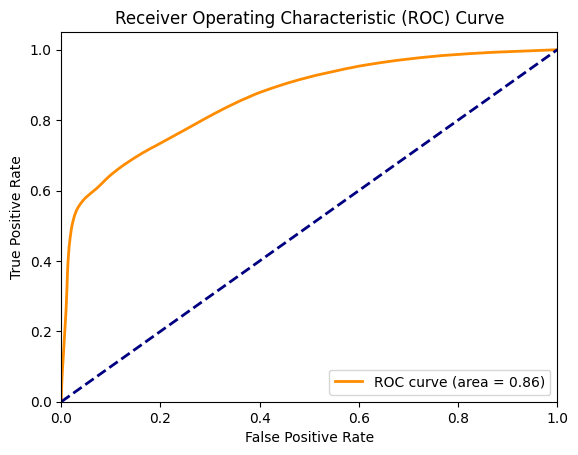

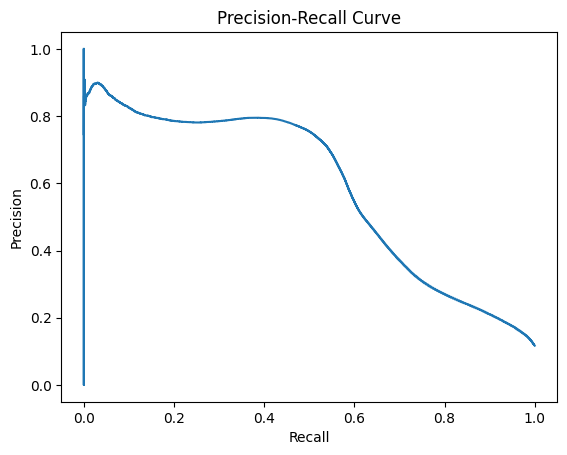

In [92]:
plot_roc_auc(logits, labels)
plot_prc_curve(logits, labels)

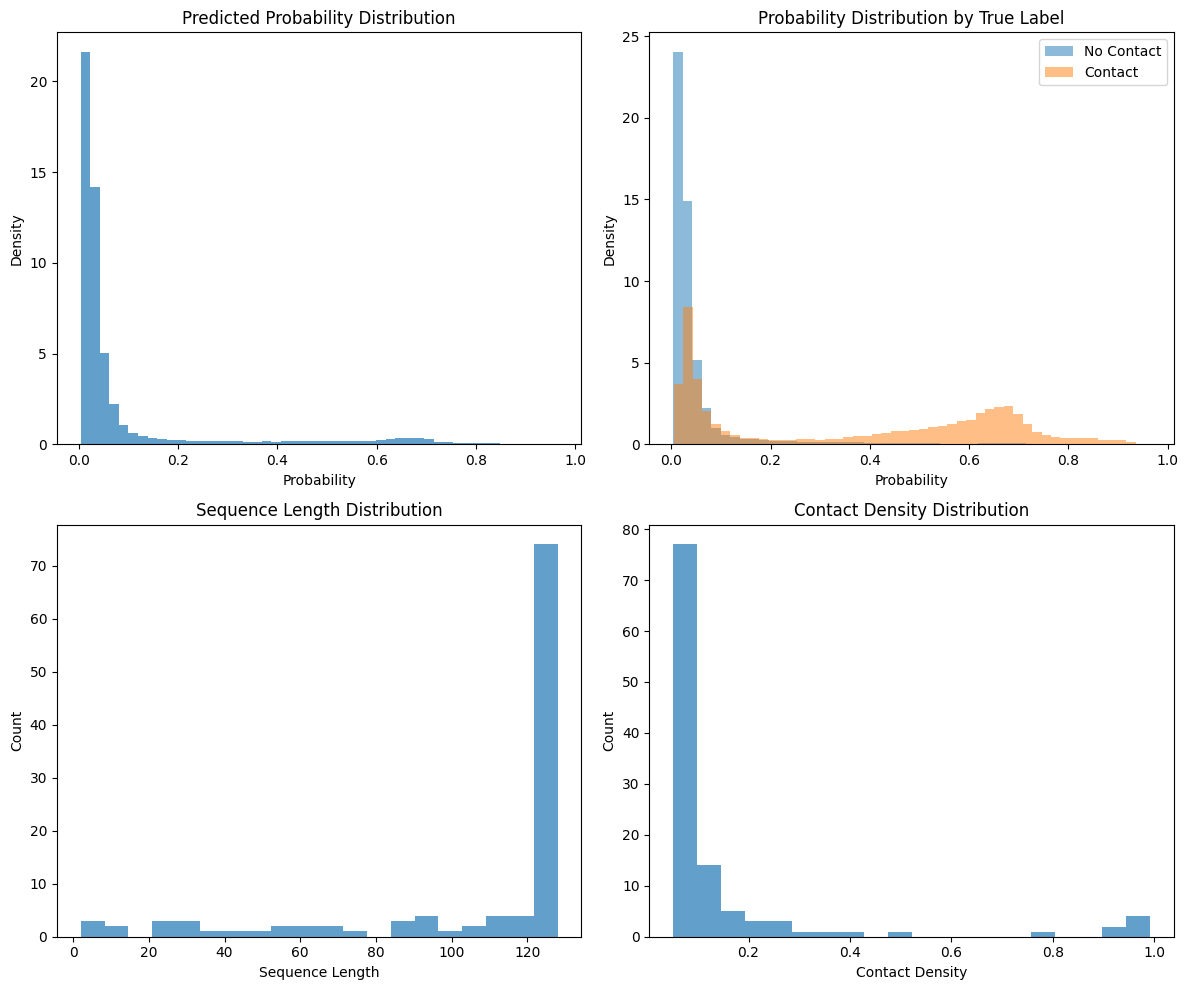

總樣本數: 113
平均序列長度: 107.0
平均接觸密度: 0.1568


In [95]:
def plot_contact_statistics(logits_list, labels_list, labels_mask_list):
    """繪製整個測試集的統計分析"""
    
    logits_tensor = torch.cat(logits_list, dim=0)
    labels_tensor = torch.cat(labels_list, dim=0)
    masks_tensor = torch.cat(labels_mask_list, dim=0)
    
    # 計算所有有效位置的統計
    valid_indices = masks_tensor == 1
    all_logits = logits_tensor[valid_indices]
    all_labels = labels_tensor[valid_indices]
    all_probs = torch.sigmoid(all_logits)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 機率分佈直方圖
    axes[0, 0].hist(all_probs.numpy(), bins=50, alpha=0.7, density=True)
    axes[0, 0].set_title('Predicted Probability Distribution')
    axes[0, 0].set_xlabel('Probability')
    axes[0, 0].set_ylabel('Density')
    
    # 按真實標籤分組的機率分佈
    pos_probs = all_probs[all_labels == 1].numpy()
    neg_probs = all_probs[all_labels == 0].numpy()
    
    axes[0, 1].hist(neg_probs, bins=50, alpha=0.5, label='No Contact', density=True)
    axes[0, 1].hist(pos_probs, bins=50, alpha=0.5, label='Contact', density=True)
    axes[0, 1].set_title('Probability Distribution by True Label')
    axes[0, 1].set_xlabel('Probability')
    axes[0, 1].set_ylabel('Density')
    axes[0, 1].legend()
    
    # 序列長度分佈
    seq_lengths = []
    for i in range(len(masks_tensor)):
        seq_len = torch.sum(masks_tensor[i][0, :]).item()
        seq_lengths.append(seq_len)
    
    axes[1, 0].hist(seq_lengths, bins=20, alpha=0.7)
    axes[1, 0].set_title('Sequence Length Distribution')
    axes[1, 0].set_xlabel('Sequence Length')
    axes[1, 0].set_ylabel('Count')
    
    # 接觸密度分佈
    contact_densities = []
    for i in range(len(labels_tensor)):
        mask = masks_tensor[i]
        labels_valid = labels_tensor[i][mask == 1]
        if len(labels_valid) > 0:
            density = labels_valid.sum().item() / len(labels_valid)
            contact_densities.append(density)
    
    axes[1, 1].hist(contact_densities, bins=20, alpha=0.7)
    axes[1, 1].set_title('Contact Density Distribution')
    axes[1, 1].set_xlabel('Contact Density')
    axes[1, 1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    print(f"總樣本數: {len(logits_tensor)}")
    print(f"平均序列長度: {np.mean(seq_lengths):.1f}")
    print(f"平均接觸密度: {np.mean(contact_densities):.4f}")

# 使用範例
plot_contact_statistics(logits, labels, labels_mask)

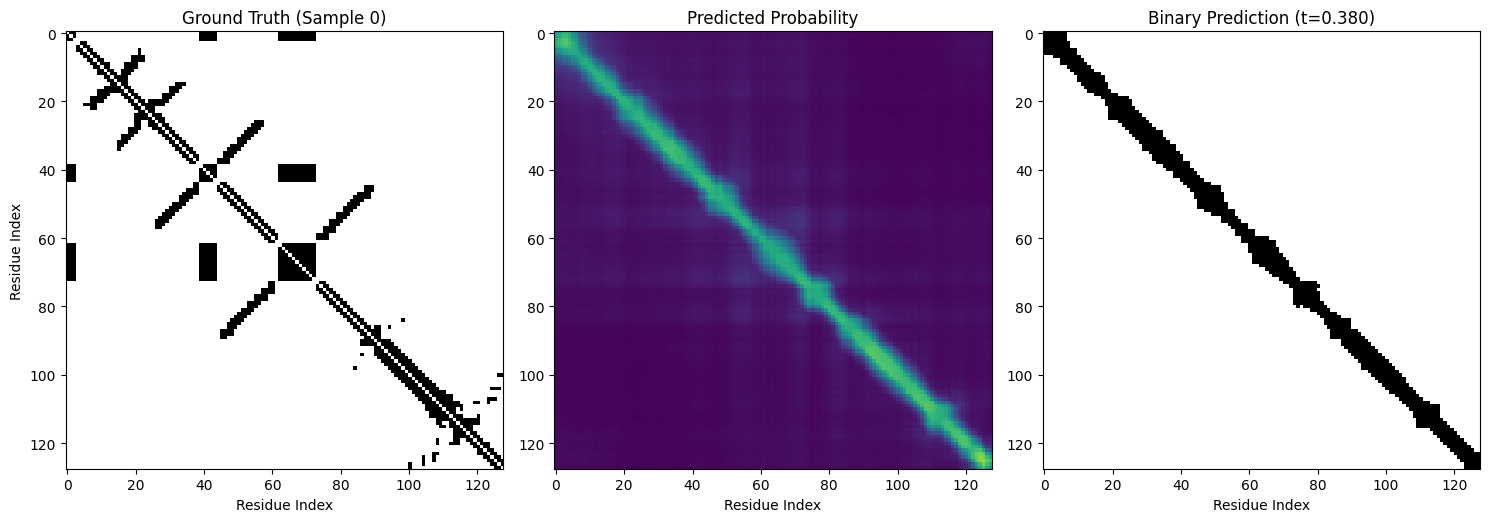

In [102]:
def plot_multiple_contact_maps(logits_list, labels_list, labels_mask_list, 
                               sample_indices=[0, 1, 2, 3], threshold=0.3798):
    """繪製多個樣本的接觸圖比較"""
    
    logits_tensor = torch.cat(logits_list, dim=0)
    labels_tensor = torch.cat(labels_list, dim=0)
    masks_tensor = torch.cat(labels_mask_list, dim=0)
    
    n_samples = len(sample_indices)
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5*n_samples))
    
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, sample_idx in enumerate(sample_indices):
        # 取得樣本數據
        logits_sample = logits_tensor[sample_idx]
        labels_sample = labels_tensor[sample_idx]
        mask_sample = masks_tensor[sample_idx]
        
        # 計算有效長度
        valid_length = torch.sum(mask_sample[0, :]).int().item()
        
        # 只取有效部分
        logits_valid = logits_sample[:valid_length, :valid_length].numpy()
        labels_valid = labels_sample[:valid_length, :valid_length].numpy()
        probs_valid = 1 / (1 + np.exp(-logits_valid))
        
        # 繪製三個子圖
        # 真實接觸圖
        axes[i, 0].imshow(labels_valid, cmap='Greys', origin='upper')
        axes[i, 0].set_title(f'Ground Truth (Sample {sample_idx})')
        axes[i, 0].set_ylabel('Residue Index')
        
        # 預測機率
        im = axes[i, 1].imshow(probs_valid, cmap='viridis', origin='upper', vmin=0, vmax=1)
        axes[i, 1].set_title(f'Predicted Probability')
        
        # 二值化預測
        pred_binary = (probs_valid > threshold).astype(int)
        axes[i, 2].imshow(pred_binary, cmap='Greys', origin='upper')
        axes[i, 2].set_title(f'Binary Prediction (t={threshold:.3f})')
        
        # 只在最後一行顯示x軸標籤
        if i == n_samples - 1:
            for j in range(3):
                axes[i, j].set_xlabel('Residue Index')
    
    plt.tight_layout()
    plt.show()

# 使用範例
plot_multiple_contact_maps(logits, labels, labels_mask, sample_indices=[0])